# Detección de loops en entornos agrícolas: relevamiento de avances

Relevamiento del trabajo sobre **StereoLoopDetector (SLD)** (Soncini, Civera y Pire, JFR 2024), rama `claude`.
Protocolo: **FieldSAFE = train** (desarrollo y ajuste de parámetros), **RosarioV2 = validación** (sin reajustar
nada). Todas las tablas y figuras se recalculan acá a partir de las salidas guardadas en `evaluation/runs/`.

| Cap. | Tema |
|---|---|
| 1 | Protocolo de evaluación y métricas |
| 2 | Diagnóstico del SLD original y corrección del ground truth |
| 3 | Arreglos al detector (bugs del PnP y del estéreo) |
| 4 | Odometría visual: ventana de exclusión por distancia |
| 5 | Recuperación de candidatos con DINOv2‑SALAD |
| 6 | Puntos lejanos como rayos |
| 7 | Verificación con features aprendidas (ALIKED + LightGlue) |
| 8 | Filtro de consistencia con la odometría |
| 9 | RosarioV2 a resolución nativa (1280×720) |
| 10 | Impacto en la trayectoria (ATE) |
| 11 | Aliasing entre surcos e interior del campo |
| 12 | Conclusión final: SLD original vs pipeline nuevo |

Para reproducir: correr las celdas en orden con el entorno `.venv` del repo, desde `evaluation/`.

In [1]:
import sys, json, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, '.')
from datasets import select
from sld_eval import load_gt, evaluate, summarize, load_run, pose_errors, wrap, R_M, S_M
RUNS = Path('runs')
pd.set_option('display.precision', 3); pd.set_option('display.width', 160)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e5e4df', 'grid.linewidth': .6, 'axes.axisbelow': True,
                     'font.size': 9})
C_BASE, C_NEW, C_ALT = '#8a8f98', '#2a78d6', '#eb6834'

_GT = {}
def gt_of(s):
    if s.name not in _GT:
        _GT[s.name] = load_gt(s.poses)
    return _GT[s.name]

def metrics(run, sessions):
    '''Metricas por sesion + total (micro-promedio) de una corrida.'''
    rows = []
    for s in select(sessions):
        f = RUNS / run / f'{s.name}_results.yml'
        if not f.exists() or 'num_images' not in f.read_text():
            continue
        m, _ = evaluate(f, gt_of(s))
        rows.append(dict(session=s.name, **m))
    df = pd.DataFrame(rows)
    tot = dict(session='TOTAL', **summarize(df.to_dict('records')))
    return pd.concat([df, pd.DataFrame([tot])], ignore_index=True)

COLS = {'loops': 'Loops', 'trivial': 'Triviales', 'tp': 'TP (<3 m)', 'fp': 'FP (≥3 m)', 'precision': 'Precisión',
        'recall': 'Recall', 'coverage': 'Cobertura', 'pose_ok': 'Pose correcta', 'e_vec_med': 'e_vec med [m]',
        'e_yaw_med': 'e_yaw med [°]'}

def tabla(runs, sessions):
    '''Una fila por configuracion con el total sobre las sesiones dadas.'''
    out = {}
    for label, run in runs.items():
        t = metrics(run, sessions).iloc[-1]
        out[label] = {v: t.get(k, np.nan) for k, v in COLS.items()}
    df = pd.DataFrame(out).T
    for c in ['Loops', 'Triviales', 'TP (<3 m)', 'FP (≥3 m)', 'Pose correcta']:
        df[c] = df[c].astype(float).round(0).astype('Int64')
    return df

FS = 'fieldsafe'
FS3 = 'fs_static1,fs_dynamic1,fs_dynamic2'          # las 3 sesiones del paper original
RO = 'rosario'                                       # 640x360
ROF = 'rosariofr'                                    # 1280x720 (resolucion nativa)

## 1. Protocolo de evaluación y métricas

**Idea.** El paper original reporta solo el error mediano de traslación de los loops detectados, sin precisión
ni recall ni una definición de qué es un loop correcto. Para comparar métodos hace falta un protocolo que diga qué
loops existen (ground truth) y cuáles de los detectados sirven.

**Fuentes.** Métricas estándar de loop closure y VPR: precisión/recall, recall a 100 % de precisión (Gálvez‑López
y Tardós, *Bags of Binary Words…*, T‑RO 2012; GV‑Bench, Yu et al., IROS 2024); ATE tras optimizar el grafo de poses
(Sturm et al., *A benchmark for the evaluation of RGB‑D SLAM systems*, IROS 2012; ROVER, arXiv 2508.13488).

**Definiciones** (`sld_eval.py`):
- **Revisita GT:** frame con otro frame anterior a menos de **3 m**, con **≥ 20 m de camino** entre ambos y en el
  mismo sentido de marcha (|Δyaw| < 60°).
- **Clasificación de cada loop:** **TP** (< 3 m y ≥ 20 m de camino), **trivial** (< 20 m de camino: típicamente el
  robot detenido viéndose a sí mismo, correcto pero inútil para SLAM) y **FP** (≥ 3 m).
- **Precisión** = TP / (TP + FP); **recall** = frames revisita con un TP / frames revisita.
- **Cobertura** (métrica propia): fracción de tramos de 10 m de trayecto revisitado con al menos un TP. Mide si
  los loops están repartidos a lo largo del recorrido, que es lo que necesita un SLAM, y no solo cuántos hay.
- **Pose correcta** (`pose_ok`): loops no triviales con error de traslación planar e_vec < 1 m y de yaw < 10°, a
  cualquier distancia. Cuenta como útil la pasada vecina (3–10 m) si la pose relativa es correcta.
- **ATE**: RMSE de posición tras optimizar un grafo de poses SE(2) con la odometría visual más los loops (cap. 10).

**Orientación de referencia:** heading del GPS de doble antena en FieldSAFE y eje óptico del GT 6DoF en Rosario.

## 2. Diagnóstico del SLD original y corrección del ground truth

**Idea.** Antes de mejorar el detector, entender qué detecta. El paper reporta "mediana de 15 cm" de error en
FieldSAFE; con métricas que separan loops triviales, la foto cambia.

**Fuentes.** SLD (Soncini, Civera y Pire, *Addressing the challenges of loop detection in agricultural
environments*, JFR 2024, [arXiv 2408.15761](https://arxiv.org/abs/2408.15761)); FieldSAFE (Kragh et al., *FieldSAFE:
Dataset for Obstacle Detection in Agriculture*, Sensors 2017); RosarioV2 (Soncini et al., 2025,
[cifasis.github.io/rosariov2](https://cifasis.github.io/rosariov2/)).

**Experimentación.**
1. SLD original sobre las 3 sesiones del paper y sobre RosarioV2.
2. Sincronización GPS–cámara de FieldSAFE: el desfase de 19.25 s del script de preparación se verificó comparando la
   velocidad de la odometría visual con la del GPS.

In [2]:
print('SLD original, FieldSAFE (3 sesiones del paper):')
display(tabla({'SLD original': 'baseline'}, FS3)[['Loops', 'Triviales', 'TP (<3 m)', 'FP (≥3 m)', 'Cobertura', 'e_vec med [m]']])
m = metrics('baseline', FS3)
print('Por sesion:'); display(m[['session', 'loops', 'tp', 'trivial', 'fp', 'coverage']])

SLD original, FieldSAFE (3 sesiones del paper):


,Loops,Triviales,TP (<3 m),FP (≥3 m),Cobertura,e_vec med [m]
SLD original,517,456,61,0,0.017,0.203


Por sesion:


,session,loops,tp,trivial,fp,coverage
0,fs_static1,198,0,198,0,0.000
1,fs_dynamic1,197,61,136,0,0.047
2,fs_dynamic2,122,0,122,0,0.000
3,TOTAL,517,61,456,0,0.017


In [3]:
# Desfase GPS-camara: retardo de la velocidad GPS respecto de la odometria visual (sin GT en la odometria)
def lag_frames(odo, cum, w=10, rng=30):
    n = min(len(odo), len(cum)); a = odo[w:n] - odo[:n - w]; b = cum[w:n] - cum[:n - w]
    best = max((np.corrcoef(a[max(0, l):len(a) + min(0, l)], b[max(0, -l):len(b) + min(0, -l)])[0, 1], l)
               for l in range(-rng, rng + 1))
    return best[1]

rows = []
for s in select('fs_static1,fs_dynamic2,fs_12-37'):
    odo = pd.read_csv(RUNS / 'p2_excl' / f'{s.name}_queries.csv').odometer.values
    old = np.loadtxt(s.prepared / f'poses_{s.seq}_offset19.25.csv', delimiter=',')[:, 1:3]
    cum_old = np.r_[0, np.cumsum(np.linalg.norm(np.diff(old, axis=0), axis=1))]
    rows.append(dict(sesion=s.name, retardo_GT_original_s=lag_frames(odo, cum_old) / 10,
                     retardo_GT_corregido_s=lag_frames(odo, gt_of(s).cum) / 10))
display(pd.DataFrame(rows))

,sesion,retardo_GT_original_s,retardo_GT_corregido_s
0,fs_static1,-1.7,0.0
1,fs_dynamic2,-1.6,0.0
2,fs_12-37,-1.4,0.0


**Conclusión.**
- En FieldSAFE el **88–100 % de los loops del SLD original son triviales**: el robot quieto más de 20 s se
  reconoce a sí mismo (la ventana de exclusión es temporal). La "mediana de 15 cm" del paper sale de esos casos.
- Solo una sesión tiene loops en movimiento, y la cobertura de revisitas es ~1 %.
- **El GT de FieldSAFE estaba desincronizado 1.5 s** (3–4.7 m de error de posición en movimiento). Dos estimaciones
  independientes coinciden (retardo de velocidad contra la odometría y máximo de loops con pose correcta); con el
  desfase corregido el retardo queda en 0. Todas las métricas de FieldSAFE usan el GT corregido.
- En Rosario el GT 6DoF es de la cámara (eje óptico ~19° hacia abajo): el yaw se toma del eje óptico proyectado.

## 3. Arreglos al detector

**Idea.** Revisando el código aparecieron errores que afectan la pose estimada del loop:
1. El **PnP usaba la matriz de cámara cruda y la distorsión**, pero las imágenes y la triangulación están
   rectificadas (en FieldSAFE la focal difiere 4 %).
2. `near_distance`/`far_distance` eran `int`: el filtro de 0.4 m se truncaba a 0.
3. PnP sin RANSAC.
4. Matches estéreo sin chequeo de disparidad (entraban puntos detrás de la cámara).

**Fuentes.** Hartley y Zisserman, *Multiple View Geometry* (rectificación y matriz de proyección); OpenCV
`solvePnPRansac`.

**Experimentación.** Cada arreglo por separado sobre FieldSAFE (3 sesiones del paper), y el sesgo de traslación con
el robot quieto (donde la verdad es ≈ 0).

In [4]:
runs = {'SLD original': 'baseline', 'K rectificada': 'p1_rectK', 'near 0.4 m': 'p1_near', 'RANSAC': 'p1_ransac',
        'disparidad > 0': 'p1_disp', 'todos (p1_all)': 'p1_all'}
display(tabla(runs, FS3)[['TP (<3 m)', 'Triviales', 'Pose correcta', 'e_vec med [m]', 'e_yaw med [°]']])

# Sesgo con el robot quieto: |t| estimado en loops triviales con desplazamiento GT < 5 cm
rows = []
for label, run in runs.items():
    tn = []
    for s in select(FS3):
        _, d = evaluate(RUNS / run / f'{s.name}_results.yml', gt_of(s))
        st = d['trivial'] & (d['gd'] < 0.05)
        tn += list(np.linalg.norm(d['t'][st], axis=1))
    rows.append(dict(config=label, n=len(tn), t_quieto_mediana_m=np.median(tn)))
display(pd.DataFrame(rows).set_index('config'))

,TP (<3 m),Triviales,Pose correcta,e_vec med [m],e_yaw med [°]
SLD original,61,456,61,0.203,1.098
K rectificada,61,456,61,0.115,1.289
near 0.4 m,61,456,61,0.203,1.098
RANSAC,16,449,16,0.093,1.658
disparidad > 0,45,456,44,0.197,1.125
todos (p1_all),40,454,40,0.056,1.070


,n,t_quieto_mediana_m
config,,
SLD original,436,0.157
K rectificada,436,0.001
near 0.4 m,436,0.157
RANSAC,436,0.101
disparidad > 0,434,0.154
todos (p1_all),434,0.001


**Conclusión.**
- **El sesgo de 0.16 m con el robot quieto era el error de intrínsecos**: con la matriz rectificada baja a 1 mm.
- Los arreglos bajan el error de pose del original (e_vec 0.20 → 0.06 m) pero **no cambian el recall**: el cuello
  de botella está antes, en la recuperación de candidatos.
- El filtro de 0.4 m no tiene efecto; RANSAC con ≥ 20 inliers descarta loops reales (la geometría en pasto tiene
  pocos inliers).

## 4. Odometría visual: ventana de exclusión por distancia

**Idea.** La ventana de exclusión de SLD es temporal (20 s): un robot detenido genera loops consigo mismo, y a
velocidad variable se pierden loops. Se reemplaza por una ventana en **distancia recorrida**, medida sin GPS con una
odometría visual estéreo mínima (PnP RANSAC 3D‑2D contra el último keyframe; el odómetro no integra el jitter del
robot quieto). También se probó relajar la verificación geométrica.

**Fuentes.** Keyframes y odometría estéreo como en ORB‑SLAM2/3 (Mur‑Artal y Tardós, T‑RO 2017; Campos et al.,
T‑RO 2021); Kaess, Ni y Dellaert, *Flow separation for fast and robust stereo odometry*, ICRA 2009.

**Experimentación.** `demo/StereoOdometry.hpp`; exclusión de 20 m (`p2_excl`) y combinación con verificación
permisiva (sin chequeo L‑L/R‑R, ratio 0.8, 3 candidatos, bypass temporal con ≥ 60 inliers: `p2_combo`).

In [5]:
display(tabla({'SLD original': 'baseline', 'arreglos (p1_all)': 'p1_all', '+ exclusión 20 m (p2_excl)': 'p2_excl',
               '+ verificación permisiva (p2_combo)': 'p2_combo'}, FS)
        [['Loops', 'Triviales', 'TP (<3 m)', 'FP (≥3 m)', 'Cobertura', 'Pose correcta', 'e_vec med [m]']])

,Loops,Triviales,TP (<3 m),FP (≥3 m),Cobertura,Pose correcta,e_vec med [m]
SLD original,2716,2651,65,0,0.013,65,0.197
arreglos (p1_all),2613,2573,40,0,0.006,40,0.056
+ exclusión 20 m (p2_excl),39,0,39,0,0.007,39,0.053
+ verificación permisiva (p2_combo),179,0,177,2,0.026,177,0.128


**Conclusión.**
- **La exclusión por distancia elimina el 100 % de los loops triviales sin perder loops reales y sin GPS.**
- Aflojar la verificación con ORB da ~4× más loops reales, pero la cobertura sigue en ~2–3 %: no alcanza con
  ajustar umbrales, falta información en las etapas anteriores.

## 5. Recuperación de candidatos con DINOv2‑SALAD

**Idea.** Un análisis por etapas mostró que en FieldSAFE **el candidato de BoW es correcto solo ~8 % de las veces**
en revisitas reales (pasto homogéneo: aliasing perceptual). Ningún ajuste posterior recupera esos loops. Se prueba un
descriptor global aprendido para proponer candidatos.

**Fuentes.** DINOv2 (Oquab et al., TMLR 2024); **SALAD** (Izquierdo y Civera, *Optimal Transport Aggregation for
Visual Place Recognition*, CVPR 2024); AnyLoc (Keetha et al., RA‑L 2023) sobre VPR en entornos no estructurados.

**Experimentación.** Descriptor SALAD por imagen, **PCA a 256‑D ajustada solo con FieldSAFE** y aplicada sin cambios
a Rosario. Recall@K sobre los frames revisita (acierto si alguno de los K más similares está a < 3 m) e integración
en el detector como reemplazo de la consulta BoW (`global_retrieval`).

In [6]:
from retrieval_eval import recall_at_k
from datasets import CACHE
rows = []
for ds in (FS, RO):
    tot, n = np.zeros(4), 0
    for s in select(ds):
        f = CACHE / f'{s.dataset}_{s.seq}_salad.npy'
        if not f.exists(): continue
        r, k = recall_at_k(np.load(f), gt_of(s), stride=10)
        tot += np.array(list(r.values())) * k; n += k
    rows.append(dict(dataset=ds, **{f'R@{k}': v for k, v in zip((1, 5, 10, 25), tot / max(n, 1))}))
display(pd.DataFrame(rows).set_index('dataset'))
display(tabla({'p2_excl (BoW)': 'p2_excl', 'SALAD (p3_salad)': 'p3_salad', 'SALAD + 5 candidatos (p3_salad_c5)': 'p3_salad_c5'}, FS)
        [['TP (<3 m)', 'FP (≥3 m)', 'Cobertura', 'Pose correcta']])

,R@1,R@5,R@10,R@25
dataset,,,,
fieldsafe,0.347,0.643,0.762,0.873
rosario,0.644,0.734,0.776,0.831


,TP (<3 m),FP (≥3 m),Cobertura,Pose correcta
p2_excl (BoW),39,0,0.007,39
SALAD (p3_salad),33,0,0.008,33
SALAD + 5 candidatos (p3_salad_c5),57,0,0.014,57


**Conclusión.**
- SALAD pone el lugar correcto primero el 34 % de las veces en FieldSAFE (BoW: ~8 %) y el 63 % en Rosario, y entre
  los 10 primeros el 72–77 %. El resultado se sostiene en Rosario sin reajuste.
- Integrado con la verificación ORB **casi no suma loops**: la verificación ORB rechaza miles de candidatos correctos
  (mediana de 7 matches en pares correctos). El cuello de botella pasa a la verificación (cap. 7).

## 6. Puntos lejanos como rayos

**Idea.** La profundidad estéreo de un punto lejano es mala, pero su **dirección** es excelente. En lugar de
descartarlo, se usa como un rayo de profundidad desconocida mayor a un umbral: su residuo es el mínimo error de
reproyección a lo largo del rayo. Los puntos cercanos dan escala y traslación; los lejanos, soporte y rotación.

**Fuentes.** Kaess, Ni y Dellaert, ICRA 2009 (separación de flujo cercano/lejano); Paz et al., *Large‑scale 6‑DOF SLAM
with stereo‑in‑hand*, T‑RO 2008 (parametrización por profundidad inversa).

**Experimentación.** `max_depth_rel_error` (descartar puntos con > 10 % de error de profundidad esperado) y
`hybrid_far` (rayos lejanos) sobre `p2_excl`; también la máscara fija del tractor en FieldSAFE.

In [7]:
display(tabla({'p2_excl': 'p2_excl', 'máscara del tractor': 'p4_mask', 'descartar lejanos': 'p4_depth',
               'lejanos como rayos (p4_hybrid)': 'p4_hybrid'}, FS)[['TP (<3 m)', 'FP (≥3 m)', 'Pose correcta', 'e_vec med [m]', 'e_yaw med [°]']])

,TP (<3 m),FP (≥3 m),Pose correcta,e_vec med [m],e_yaw med [°]
p2_excl,39,0,39,0.053,1.174
máscara del tractor,36,0,36,0.075,1.570
descartar lejanos,19,0,19,0.050,1.205
lejanos como rayos (p4_hybrid),53,0,53,0.076,1.322


**Conclusión.**
- Descartar los puntos lejanos mejora la pose pero pierde la mitad de los loops; **usarlos como rayos los recupera y
  suma (+36 % de TP con precisión 1.00)**. Los puntos lejanos sirven para verificar aunque su profundidad no.
- La máscara del tractor no cambia nada con BoW + ORB.

## 7. Verificación con features aprendidas (ALIKED + LightGlue)

**Idea.** Con SALAD llegan candidatos correctos, pero ORB no encuentra correspondencias suficientes en pasto. Se
prueba la verificación con detectores/descriptores aprendidos y un matcher aprendido.

**Fuentes.** **ALIKED** (Zhao et al., *ALIKED: A Lighter Keypoint and Descriptor Extraction Network via Deformable
Transformation*, IEEE TIM 2023); **LightGlue** (Lindenberger, Sarlin y Pollefeys, ICCV 2023); SuperPoint (DeTone et
al., CVPRW 2018); DISK (Tyszkiewicz et al., NeurIPS 2020); GV‑Bench (Yu et al., IROS 2024).

**Experimentación.**
1. *Offline* (`verify_offline.py`): 150 pares correctos que ORB rechazó y 150 pares a > 10 m; inliers de una matriz
   esencial RANSAC.
2. *Etapa de verificación* (`learned_verify.py`): ALIKED + LightGlue entre izquierdas, profundidad por matching
   estéreo con ALIKED, PnP RANSAC con los puntos cercanos y rayos lejanos; acepta ≥ 15 inliers cercanos y ≥ 60 totales.

In [8]:
v = pd.read_csv(RUNS / 'p3_salad' / 'verify_offline.csv')
rows = []
for mth in ('orb', 'superpoint', 'disk', 'aliked'):
    pos, neg = v[v.label == 1][f'{mth}_inliers'], v[v.label == 0][f'{mth}_inliers']
    rows.append(dict(metodo=mth, inliers_correctos=pos.median(), inliers_incorrectos=neg.median(),
                     recall_a_0_FP=(pos >= neg.max() + 1).mean()))
display(pd.DataFrame(rows).set_index('metodo'))
display(tabla({'SALAD + ORB (p3_salad_c5)': 'p3_salad_c5', 'SALAD + ALIKED/LightGlue (p5_aliked)': 'p5_aliked'}, FS)
        [['Loops', 'TP (<3 m)', 'FP (≥3 m)', 'Cobertura', 'Pose correcta', 'e_vec med [m]', 'e_yaw med [°]']])

,inliers_correctos,inliers_incorrectos,recall_a_0_FP
metodo,,,
orb,76.0,32.0,0.107
superpoint,219.0,117.5,0.767
disk,311.5,41.0,0.860
aliked,384.0,85.5,0.953


,Loops,TP (<3 m),FP (≥3 m),Cobertura,Pose correcta,e_vec med [m],e_yaw med [°]
SALAD + ORB (p3_salad_c5),57,57,0,0.014,57,0.078,1.834
SALAD + ALIKED/LightGlue (p5_aliked),16948,7556,9363,0.740,16270,0.138,1.201


**Conclusión.**
- ALIKED + LightGlue **recupera el 95 % de los pares correctos que ORB descartaba, sin falsos en la muestra**
  (ORB: 11 %).
- Integrado, **es el cambio de mayor impacto**: en FieldSAFE la cobertura pasa de ~1 % a ~74 % y los loops con pose
  correcta de decenas a más de 16 000.
- Los "FP" de FieldSAFE son casi todos la pasada vecina del tractor (3–10 m) con pose correcta: el criterio de 3 m
  queda chico y la métrica relevante es `Pose correcta`.

## 8. Filtro de consistencia con la odometría

**Idea.** En Rosario aparecían loops falsos a lo largo del mismo surco, 20–35 m adelante: el horizonte no cambia y
las hileras se repiten, y el PnP estima ~0.2 m cuando la verdad es ~22 m. La odometría visual sabe cuánto avanzó el
robot en ese tramo: un loop incompatible con ella se rechaza.

**Fuentes.** PCM (Mangelson et al., *Pairwise Consistent Measurement Set Maximization for Robust Multi‑robot Map
Merging*, ICRA 2018); RRR (Latif, Cadena y Neira, IJRR 2013); ROVER (arXiv 2508.13488), consistencia con prior de
trayectoria en entornos repetitivos.

**Experimentación.** `odo_filter.py`: si el camino de la odometría entre match y query es < 100 m, se rechaza el loop
cuando su desplazamiento difiere del de la odometría en más de 0.2·camino + 1 m (tolerancia que crece con la deriva).

In [9]:
for ds in (FS, ROF):
    print(ds)
    display(tabla({'p5_aliked': 'p5_aliked', '+ filtro de odometría (p6_odo)': 'p6_odo'}, ds)
            [['Loops', 'Triviales', 'TP (<3 m)', 'FP (≥3 m)', 'Precisión', 'Cobertura', 'Pose correcta']])

fieldsafe


,Loops,Triviales,TP (<3 m),FP (≥3 m),Precisión,Cobertura,Pose correcta
p5_aliked,16948,29,7556,9363,0.447,0.74,16270
+ filtro de odometría (p6_odo),16878,0,7556,9322,0.448,0.74,16270


rosariofr


,Loops,Triviales,TP (<3 m),FP (≥3 m),Precisión,Cobertura,Pose correcta
p5_aliked,13866,173,13424,269,0.980,0.6,12615
+ filtro de odometría (p6_odo),13667,165,13424,78,0.994,0.6,12615


**Conclusión.**
- En Rosario elimina la mayoría del aliasing **a lo largo del mismo surco** sin perder loops reales; en FieldSAFE no
  descarta ningún loop con pose correcta.
- Más allá de ~100 m de camino no sirve: la odometría acumula ~25 % de deriva. Ahí queda el aliasing **entre surcos**
  (cap. 11).

## 9. RosarioV2 a resolución nativa (1280×720)

**Idea.** Las imágenes de Rosario se habían extraído a 640×360. La cámara IR de la RealSense tiene una línea de base
de 5 cm: con f·B = 16 px·m la profundidad estéreo solo es confiable hasta ~3 m. A resolución nativa f·B se duplica.

**Fuentes.** RealSense D435i (Intel); Rosario v2 (calibración Kalibr única para todo el dataset, verificada contra el
`camera_info` de los bags).

**Experimentación.** Re‑extracción de las 6 secuencias a 1280×720 y mismo pipeline, sin reajuste (SALAD reutilizado:
mismos frames).

In [10]:
t = pd.concat({'640×360': tabla({'SLD original': 'baseline', 'pipeline (p6_odo)': 'p6_odo'}, RO),
               '1280×720': tabla({'SLD original': 'baseline', 'pipeline (p6_odo)': 'p6_odo'}, ROF)})
display(t[['Loops', 'TP (<3 m)', 'FP (≥3 m)', 'Precisión', 'Cobertura', 'Pose correcta', 'e_vec med [m]']])
m = metrics('p6_odo', ROF)
print('Pipeline a 1280x720, por secuencia:')
display(m[['session', 'tp', 'fp', 'precision', 'coverage', 'pose_ok', 'e_vec_med']])

Loops  TP (<3 m)  FP (≥3 m)  Precisión  Cobertura  Pose correcta  e_vec med [m]
640×360  SLD original        4607       3975          0      1.000      0.276           3892          0.041
         pipeline (p6_odo)  13740      12466       1207      0.912      0.595          11556          0.068
1280×720 SLD original        3480       2819          0      1.000      0.238           2764          0.049
         pipeline (p6_odo)  13667      13424         78      0.994      0.600          12615          0.068

Pipeline a 1280x720, por secuencia:


,session,tp,fp,precision,coverage,pose_ok,e_vec_med
0,rof_1222_1314,6924,8,0.999,0.920,6897,0.037
1,rof_1222_1429,1257,8,0.994,0.846,824,0.121
2,rof_1222_1631,155,43,0.783,0.280,32,1.214
3,rof_1226_1339,2067,15,0.993,0.322,2062,0.069
4,rof_1226_1510,2284,0,1.000,1.000,2070,0.060
5,rof_1226_1548,737,4,0.995,1.000,730,0.047
6,TOTAL,13424,78,0.994,0.600,12615,0.068


**Conclusión.**
- A resolución nativa **los falsos positivos caen 94 % (1207 → 78) y la precisión sube a 0.994**, con la misma
  cobertura. Desde acá Rosario se evalúa a 1280×720.
- El SLD original rinde peor a 1280×720 que a 640×360 (2000 ORB cubren mal la imagen grande): la comparación final
  usa cada método a la misma resolución nativa.

## 10. Impacto en la trayectoria (ATE)

**Idea.** Que los loops sean correctos no garantiza que sirvan. Se mide lo que importa en SLAM: cuánto corrigen la
trayectoria.

**Fuentes.** Sturm et al., IROS 2012 (ATE); Kümmerle et al., *g2o*, ICRA 2011 (optimización de grafos de poses);
GV‑Bench y ROVER (evaluación por impacto en la trayectoria).

**Experimentación.** `ate_eval.py`: nodos cada 5 frames, aristas de odometría visual estéreo (sin GPS), una arista
por loop (hasta 3000 por sesión), mínimos cuadrados, alineación rígida 2D al GT y RMSE de posición.

In [11]:
def ate_table(f):
    d = pd.read_csv(RUNS / f).set_index('session')
    d = d[d.path_m > 200]
    return pd.DataFrame({'recorrido [km]': d.path_m / 1000, 'solo odometría [m]': d.odom,
                         '+ loops SLD original [m]': d.baseline, '+ loops pipeline [m]': d.p6_odo,
                         'reducción vs original': 1 - d.p6_odo / d.baseline}).round(2)
print('FieldSAFE'); display(ate_table('ate_fieldsafe.csv'))
print('RosarioV2 1280x720'); display(ate_table('ate_rosariofr.csv'))

FieldSAFE


,recorrido [km],solo odometría [m],+ loops SLD original [m],+ loops pipeline [m],reducción vs original
session,,,,,
fs_static1,2.10,84.36,84.35,38.90,0.54
fs_dynamic1,3.13,24.63,23.73,11.06,0.53
fs_dynamic2,4.18,44.18,44.18,8.14,0.82
fs_12-37,4.69,46.69,46.41,7.69,0.83


RosarioV2 1280x720


,recorrido [km],solo odometría [m],+ loops SLD original [m],+ loops pipeline [m],reducción vs original
session,,,,,
rof_1222_1314,0.79,80.19,79.37,9.47,0.88
rof_1222_1429,0.90,36.01,10.74,9.22,0.14
rof_1222_1631,0.95,47.36,47.36,16.66,0.65
rof_1226_1339,2.25,100.98,101.45,72.49,0.29
rof_1226_1510,0.71,65.80,58.52,38.45,0.34
rof_1226_1548,1.74,107.67,107.67,96.70,0.10


**Conclusión.**
- En FieldSAFE los loops del pipeline reducen el ATE **54–84 %**; los del SLD original no lo cambian.
- En Rosario lo reducen en las 6 secuencias (10–88 %), pero el ATE queda alto en las secuencias largas: **la odometría
  visual a 1280×720 deriva 36–108 m** y con un grafo L2 los loops no alcanzan a corregirla. Es un límite de la
  odometría, no del detector, y queda fuera del alcance de este trabajo.

## 11. Aliasing entre surcos e interior del campo

**Idea.** En cultivos en hileras dos surcos distintos se ven casi idénticos. La geometría encuentra correspondencias
consistentes con el surco equivocado y estima "mismo lugar" (~0.1 m) cuando el robot está a 5–9 m. Además, casi todos
los loops caen en las cabeceras: en 13:39 hay 2066 loops reales en el borde y 1 en el interior.

**Fuentes.** Chebrolu et al., *Robot Localization Based on Aerial Images for Precision Agriculture Tasks in Crop
Fields*, ICRA 2019 (los huecos de cultivo rompen la ambigüedad entre hileras: 54.5 → 4–5 cm); Kraemer et al., IROS‑WS
2017; de Silva et al., arXiv 2509.18342 (aliasing por hilera en viñedos); Woebbecke et al. 1995 y Meyer y Camargo Neto
2008 (índices de vegetación). Detalle en `INVESTIGACION.md`.

**Experimentación.**
1. **Test de unicidad del lugar** (`uniqueness.py`): verificar con ALIKED las mejores alternativas SALAD de otras
   pasadas; si alguna verifica parecido al match, el lugar es ambiguo.
2. **Firma de huecos de cultivo** (idea propuesta para este trabajo; agente investigador, `research/`): segmentar la
   vegetación en IR, proyectarla al suelo y acumularla con la odometría en un perfil de ocupación por hilera; alinear
   firmas entre pasadas para obtener la hilera y el corrimiento a lo largo. Probada como **veto** (`sig_veto.py`) y como
   **generador** de loops del interior (`gen_loops.py`).

In [12]:
rows = []
for s in ('rof_1222_1631', 'rof_1226_1339', 'rof_1222_1314'):
    d = pd.read_csv(RUNS / 'p7_unique' / f'{s}_unique.csv'); fp = d.gd_match >= 3; ratio = d.alt / d.main.clip(lower=1)
    k = ratio < 0.5
    rows.append(dict(secuencia=s, TP=int((~fp).sum()), FP=int(fp.sum()), razon_med_TP=ratio[~fp].median(),
                     razon_med_FP=ratio[fp].median(), FP_que_quedan=int((fp & k).sum()), TP_que_quedan=int((~fp & k).sum())))
print('Test de unicidad (rechazar si razon alternativa/match >= 0.5):')
display(pd.DataFrame(rows).set_index('secuencia'))

Test de unicidad (rechazar si razon alternativa/match >= 0.5):


,TP,FP,razon_med_TP,razon_med_FP,FP_que_quedan,TP_que_quedan
secuencia,,,,,,
rof_1222_1631,155,43,0.000,0.539,17,150
rof_1226_1339,2100,15,0.780,0.585,4,882
rof_1222_1314,600,0,0.024,NaN,0,430


In [13]:
# Generador por firma: loops nuevos (consultas que el pipeline no tenia) y su pose
rows = []
for s in select(ROF):
    g = gt_of(s)
    _, q0, *_ = load_run(RUNS / 'p6_odo' / f'{s.name}_results.yml')
    _, q, m, t, r = load_run(RUNS / 'p9_gen' / f'{s.name}_results.yml')
    new = ~np.isin(q, q0)
    if not new.any(): continue
    ev, ey = pose_errors(g, q[new], m[new], t[new], r[new])
    rows.append(dict(secuencia=s.name, loops_nuevos=int(new.sum()), pose_correcta=int(((ev < 1) & (ey < 10)).sum()),
                     e_vec_med=np.median(ev), e_yaw_med=np.median(ey)))
display(pd.DataFrame(rows).set_index('secuencia'))
a = pd.read_csv(RUNS / 'ate_rof_1226_1339,rof_1226_1510.csv').set_index('session')
display(a[['odom', 'p6_odo', 'p9_gen']].rename(columns={'odom': 'ATE solo odometría', 'p6_odo': 'ATE pipeline',
                                                         'p9_gen': 'ATE pipeline + generador'}).round(2))

,loops_nuevos,pose_correcta,e_vec_med,e_yaw_med
secuencia,,,,
rof_1222_1314,2,2,0.076,1.949
rof_1226_1339,13,13,0.572,1.905
rof_1226_1510,11,11,0.088,5.313


,ATE solo odometría,ATE pipeline,ATE pipeline + generador
session,,,
rof_1226_1339,100.98,72.49,71.87
rof_1226_1510,65.80,38.45,38.44


**Conclusión.**
- **El test de unicidad no generaliza**: separa en 16:31, pero en el interior de 13:39 la hilera vecina verifica tan
  bien como la correcta incluso en loops reales; descarta más TP que FP.
- **La firma de huecos no sirve como veto general.** En 6 secuencias ninguna regla mejora la precisión sin destruir TP:
  los falsos están justo donde la firma no tiene información (pasada vecina a 1.3–2.6 m), y donde sí la tiene coincide
  con el PnP.
- **Sí funciona como generador de loops del interior**: 114/114 loops aceptados correctos, todos en pasadas de ida y
  vuelta que la cámara frontal no puede cerrar; 26 en consultas nuevas, todos con pose correcta. Su aporte al ATE es
  marginal, porque son pocos (solo acepta pasadas a < 1.5 m) y el ATE está limitado por la deriva de la odometría.
- El aliasing entre surcos a largo camino queda como **limitación abierta**, concentrada en 16:31.

## 12. Conclusión final: SLD original vs pipeline nuevo

Comparación entre:
- **SLD original "corregido"**: el detector del paper evaluado con el protocolo de este trabajo. En FieldSAFE solo
  cuentan los loops **en movimiento** (los triviales con el robot detenido no son TP). RosarioV2 a **resolución nativa
  1280×720**. Ambos con el GT corregido.
- **Pipeline nuevo** (mejor configuración): arreglos del cap. 3 + exclusión por distancia con odometría visual (cap. 4)
  + recuperación SALAD con 5 candidatos (cap. 5) + verificación ALIKED/LightGlue con PnP estéreo y rayos lejanos
  (caps. 6–7) + filtro de consistencia con la odometría (cap. 8). En Rosario se suman los loops del generador por firma
  de huecos (cap. 11).

Todo ajustado únicamente en FieldSAFE; RosarioV2 es validación sin reajuste.

In [14]:
final = pd.concat({
    'FieldSAFE (train)': tabla({'SLD original': 'baseline', 'Pipeline nuevo': 'p6_odo'}, FS),
    'RosarioV2 1280×720 (validación)': tabla({'SLD original': 'baseline', 'Pipeline nuevo': 'p9_gen'}, ROF)})
final['Loops no triviales'] = (final['Loops'] - final['Triviales']).astype('Int64')
display(final[['Loops no triviales', 'TP (<3 m)', 'FP (≥3 m)', 'Precisión', 'Recall', 'Cobertura', 'Pose correcta',
               'e_vec med [m]', 'e_yaw med [°]']])
fa = pd.read_csv(RUNS / 'ate_fieldsafe.csv').set_index('session'); fa = fa[fa.path_m > 200]
ra = pd.read_csv(RUNS / 'ate_rosariofr.csv').set_index('session')
print('ATE medio [m] (FieldSAFE / Rosario): solo odometría %.1f / %.1f | SLD original %.1f / %.1f | pipeline nuevo %.1f / %.1f'
      % (fa.odom.mean(), ra.odom.mean(), fa.baseline.mean(), ra.baseline.mean(), fa.p6_odo.mean(), ra.p6_odo.mean()))

Loops no triviales  TP (<3 m)  FP (≥3 m)  Precisión  Recall  Cobertura  Pose correcta  e_vec med [m]  \
FieldSAFE (train)               SLD original                    65         65          0      1.000   0.002      0.013             65          0.197   
                                Pipeline nuevo               16878       7556       9322      0.448   0.228      0.740          16270          0.138   
RosarioV2 1280×720 (validación) SLD original                  2819       2819          0      1.000   0.088      0.238           2764          0.049   
                                Pipeline nuevo               13528      13450         78      0.994   0.421      0.600          12641          0.068   

                                                e_yaw med [°]  
FieldSAFE (train)               SLD original            1.264  
                                Pipeline nuevo          1.201  
RosarioV2 1280×720 (validación) SLD original            1.030  
                                Pipeline nuevo          2.222

ATE medio [m] (FieldSAFE / Rosario): solo odometría 50.0 / 73.0 | SLD original 49.7 / 67.5 | pipeline nuevo 16.4 / 40.5


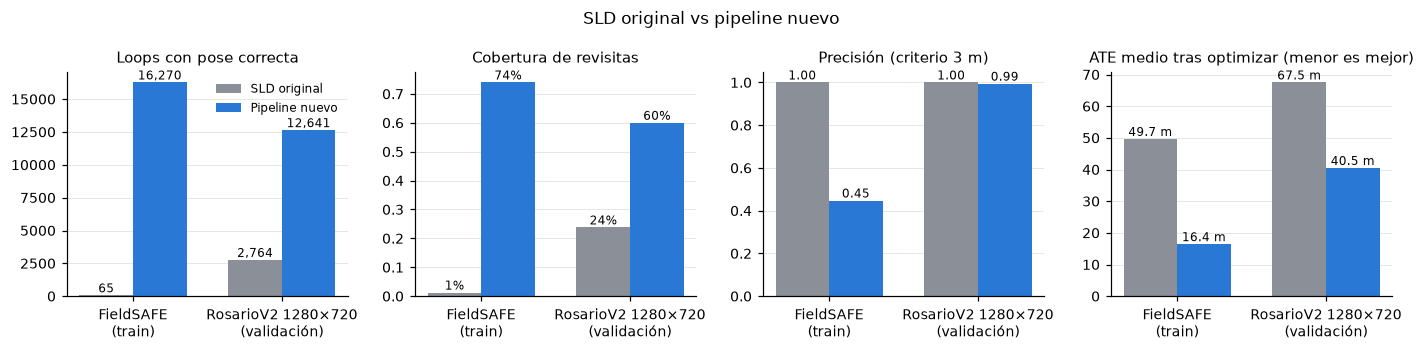

In [15]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.2))
ds_lab = ['FieldSAFE\n(train)', 'RosarioV2 1280×720\n(validación)']
x = np.arange(2); w = 0.36
def bars(ax, col, title, fmt):
    b = [final.loc[(k, 'SLD original'), col] for k in final.index.levels[0]]
    n = [final.loc[(k, 'Pipeline nuevo'), col] for k in final.index.levels[0]]
    for xs, vals, c, lab in ((x - w / 2, b, C_BASE, 'SLD original'), (x + w / 2, n, C_NEW, 'Pipeline nuevo')):
        ax.bar(xs, vals, w, color=c, label=lab)
        for xi, vi in zip(xs, vals): ax.text(xi, vi, fmt.format(vi), ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x, ds_lab); ax.set_title(title, fontsize=9.5); ax.grid(axis='x', visible=False)
bars(axs[0], 'Pose correcta', 'Loops con pose correcta', '{:,.0f}')
bars(axs[1], 'Cobertura', 'Cobertura de revisitas', '{:.0%}')
bars(axs[2], 'Precisión', 'Precisión (criterio 3 m)', '{:.2f}')
ate_b = [fa.baseline.mean(), ra.baseline.mean()]; ate_n = [fa.p6_odo.mean(), ra.p6_odo.mean()]
for xs, vals, c in ((x - w / 2, ate_b, C_BASE), (x + w / 2, ate_n, C_NEW)):
    axs[3].bar(xs, vals, w, color=c)
    for xi, vi in zip(xs, vals): axs[3].text(xi, vi, f'{vi:.1f} m', ha='center', va='bottom', fontsize=8)
axs[3].set_xticks(x, ds_lab); axs[3].set_title('ATE medio tras optimizar (menor es mejor)', fontsize=9.5); axs[3].grid(axis='x', visible=False)
axs[0].legend(frameon=False, fontsize=8)
fig.suptitle('SLD original vs pipeline nuevo', fontsize=11); fig.tight_layout(); plt.show()

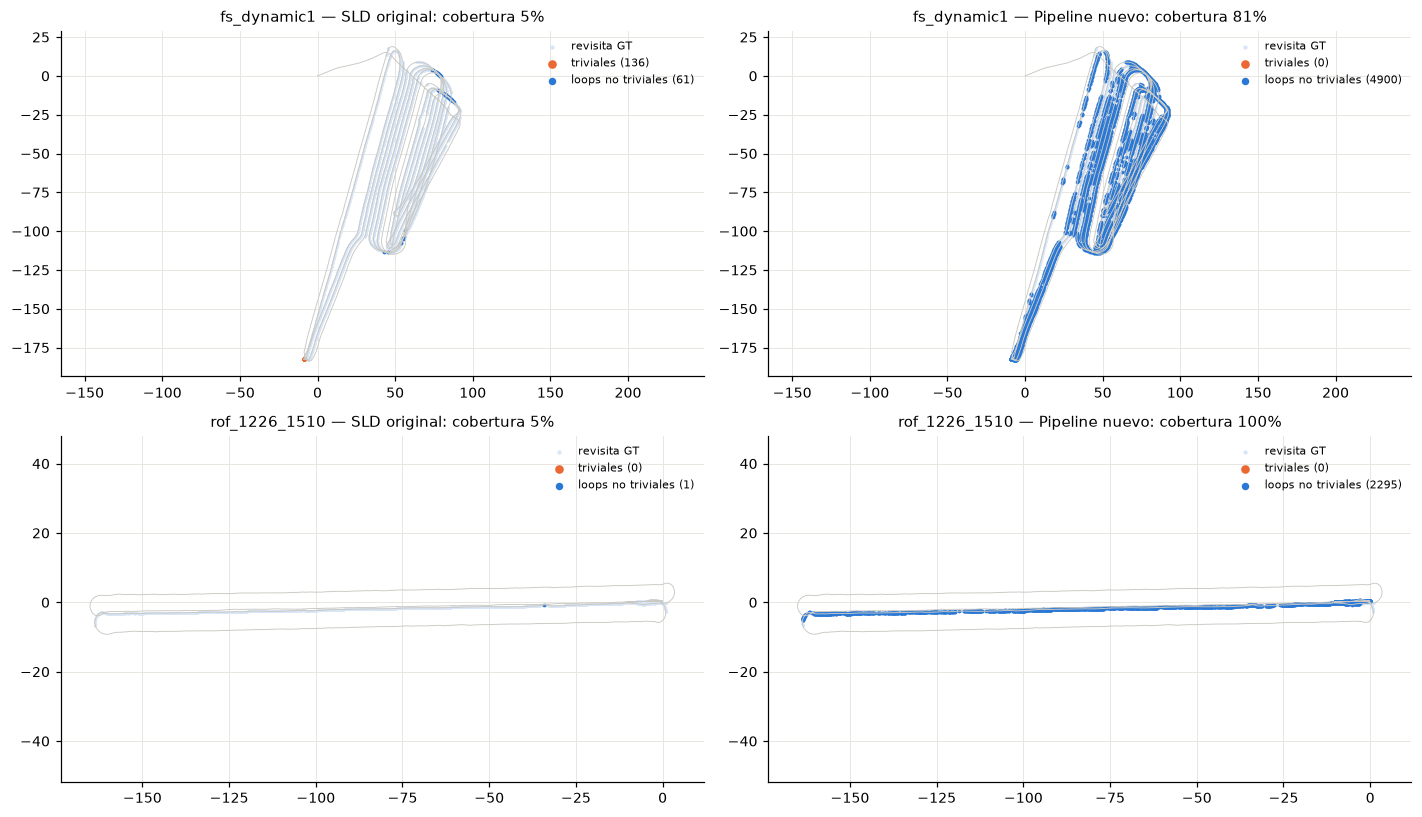

In [16]:
# Dónde caen los loops: una sesión de cada dataset
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
for row, (sn, best) in enumerate((('fs_dynamic1', 'p6_odo'), ('rof_1226_1510', 'p9_gen'))):
    s = select(sn)[0]; g = gt_of(s)
    for col, (lab, run) in enumerate((('SLD original', 'baseline'), ('Pipeline nuevo', best))):
        ax = axs[row, col]; m_, d = evaluate(RUNS / run / f'{sn}_results.yml', g)
        ax.plot(*g.xy.T, color='#c9c8c2', lw=.6)
        ax.scatter(*g.xy[g.revisit].T, s=2, color='#d9e6f7', lw=0, label='revisita GT')
        ok = ~d['trivial']
        ax.scatter(*g.xy[d['q'][d['trivial']]].T, s=8, color=C_ALT, lw=0, label=f"triviales ({d['trivial'].sum()})")
        ax.scatter(*g.xy[d['q'][ok]].T, s=6, color=C_NEW, lw=0, label=f'loops no triviales ({ok.sum()})')
        ax.set_aspect('equal', 'datalim'); ax.legend(fontsize=7, frameon=False, markerscale=2, loc='best')
        ax.set_title(f"{sn} — {lab}: cobertura {m_['coverage']:.0%}", fontsize=9.5)
fig.tight_layout(); plt.show()

### Conclusiones

1. **El pipeline nuevo, ajustado solo en FieldSAFE, se traslada a RosarioV2 sin reajuste.**
   - En **FieldSAFE**: de 65 loops en movimiento a más de 16 000 con pose correcta, cobertura de revisitas de ~1 % a
     ~74 % y ATE reducido 54–84 % por sesión.
   - En **RosarioV2 (1280×720)**: ~4.8× loops reales, ~4.6× loops con pose correcta, cobertura de ~24 % a ~60 % y
     precisión 0.994. El ATE mejora en las 6 secuencias.
2. **Qué aportó cada pieza:**
   - **Verificación con ALIKED + LightGlue:** el cambio de mayor impacto.
   - **Recuperación con SALAD:** condición necesaria para que lleguen candidatos correctos.
   - **Odometría visual estéreo, sin GPS:** elimina los loops triviales del robot detenido y, como filtro de
     consistencia, el aliasing a lo largo del surco.
   - **Resolución nativa en Rosario:** elimina el 94 % de los falsos positivos restantes.
3. **Hallazgos sobre el sistema original y los datos:**
   - error de intrínsecos en el PnP (sesgo de 0.16 m);
   - el "15 cm" del paper dominado por loops con el robot detenido;
   - GT de FieldSAFE desincronizado 1.5 s.
4. **Limitaciones abiertas:**
   - **Aliasing entre surcos a largo camino:** concentrado en la secuencia 16:31 de Rosario.
   - **Pocos loops en el interior del campo:** el generador por firma de huecos es correcto pero de bajo recall.
   - **Deriva de la odometría visual:** limita el ATE en las secuencias largas de Rosario.